<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula20a_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analisys (PCA)

In [ ]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
print(X.shape)
print(len(set(y)))

(569, 30)
2


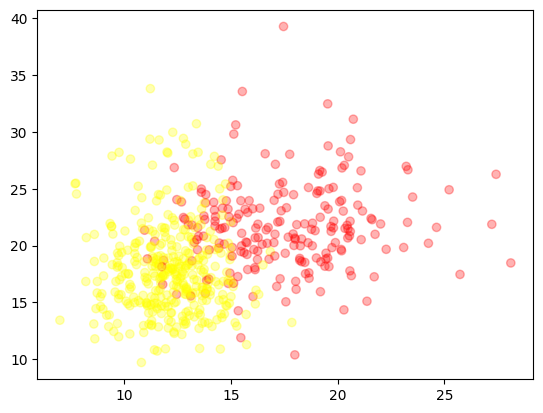

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.3, cmap="autumn")
plt.show()

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=30)
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(569, 30)


In [ ]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[9.82044672e-01 1.61764899e-02 1.55751075e-03 1.20931964e-04
 8.82724536e-05 6.64883951e-06 4.01713682e-06 8.22017197e-07
 3.44135279e-07 1.86018721e-07 6.99473205e-08 1.65908878e-08
 6.99641648e-09 4.78318305e-09 2.93549213e-09 1.41684926e-09
 8.29577731e-10 5.20405880e-10 4.08463983e-10 3.63313376e-10
 1.72849736e-10 1.27487508e-10 7.72682973e-11 6.28357715e-11
 3.57302295e-11 2.76396041e-11 8.14452259e-12 6.30211541e-12
 4.43666944e-12 1.55344680e-12]
0.9999999999999997


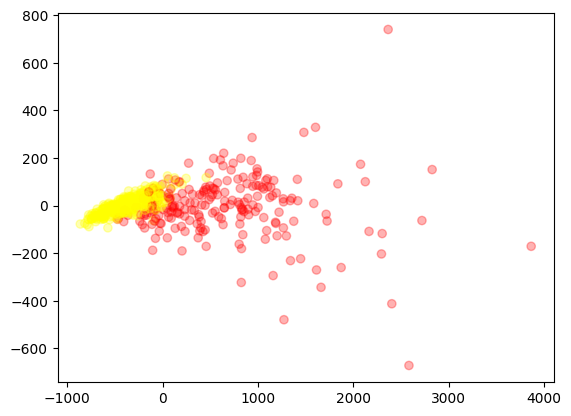

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3, cmap="autumn")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print(scores.mean())

[0.94736842 0.94736842 0.98245614 0.97368421 0.98230088]
0.9666356155876418


In [ ]:
scores = cross_val_score(clf, X_pca, y, cv=5)
print(scores)
print(scores.mean())

[0.92982456 0.92982456 0.94736842 0.96491228 0.97345133]
0.9490762303990063


In [ ]:
n_most_important_new_fetures = int(X.shape[1]*0.5)
print(n_most_important_new_fetures)
scores = cross_val_score(clf, X_pca[:,:n_most_important_new_fetures], y, cv=5)
print(scores)
print(scores.mean())

15
[0.92982456 0.92982456 0.96491228 0.94736842 0.95575221]
0.9455364073901567


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
scores = cross_val_score(clf, X, y, cv=5)
print("Espaço de características original")
print(scores)
print(scores.mean())
scores = cross_val_score(clf, X_pca[:,:n_most_important_new_fetures], y, cv=5)
print("Espaço de características transformado reduzido")
print(scores)
print(scores.mean())

Espaço de características original
[0.94736842 0.95614035 0.98245614 0.97368421 0.97345133]
0.9666200900481291
Espaço de características transformado reduzido
[0.93859649 0.93859649 0.95614035 0.94736842 0.94690265]
0.9455208818506444


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
scores = cross_val_score(clf, X, y, cv=5)
print("Espaço de características original")
print(scores)
print(scores.mean())
scores = cross_val_score(clf, X_pca[:,:n_most_important_new_fetures], y, cv=5)
print("Espaço de características transformado reduzido")
print(scores)
print(scores.mean())

Espaço de características original
[0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
0.9560937742586555
Espaço de características transformado reduzido
[0.93859649 0.92105263 0.95614035 0.95614035 0.95575221]
0.9455364073901569


In [ ]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    PCA(n_components=10),
    LogisticRegression(max_iter=1000)
)
scores = cross_val_score(model, X, y, cv=5)
print(scores)
print(scores.mean())

[0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
0.9507995652848935


In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100,
                  centers=[[0.1, 0.1], [0.1, 0.4],
                           [0.3, 0.1], [0.3, 0.4],
                           [0.5, 0.1], [0.5, 0.4],
                           [0.7, 0.1], [0.7, 0.4],
                           [0.9, 0.1], [0.9, 0.4],],
                  n_features=2,
                  cluster_std=0.05,
                  random_state=42)
y = y % 2
print(X.shape)

(100, 2)


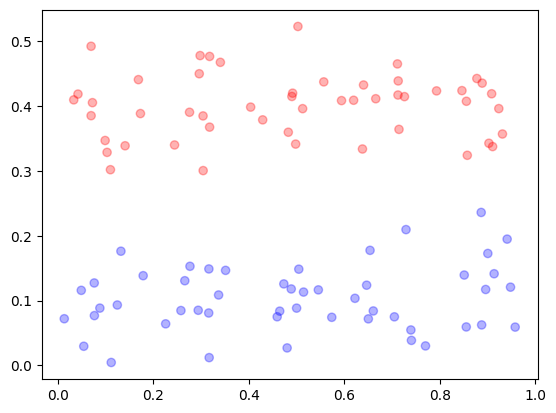

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
colors = [(0,0,1), (0,1,0), (1,0,0)]
cmap = LinearSegmentedColormap.from_list('custom_map', colors)

plt.scatter(X[:,0], X[:,1], c=y, alpha=0.3, cmap=cmap)
plt.show()

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

model = Perceptron().fit(X, y)
y_pred = model.predict(X)
print(accuracy_score(y, y_pred))

1.0


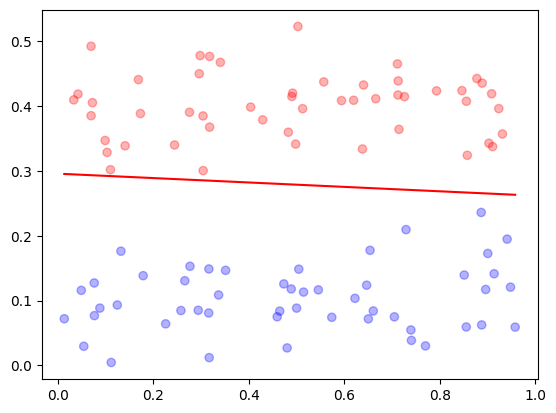

In [ ]:
import numpy as np

def plotHyperplan(vector, intercept=0, xs = [0,1]):
  xs = np.array(xs)
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, 'r-')

plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.3, cmap=cmap)
plotHyperplan(model.coef_[0], model.intercept_[0], [X[:,0].min(), X[:,0].max()])
plt.show()

In [ ]:
model = Perceptron().fit(X[:,1:], y)
y_pred = model.predict(X[:,1:])
print(accuracy_score(y, y_pred))

1.0


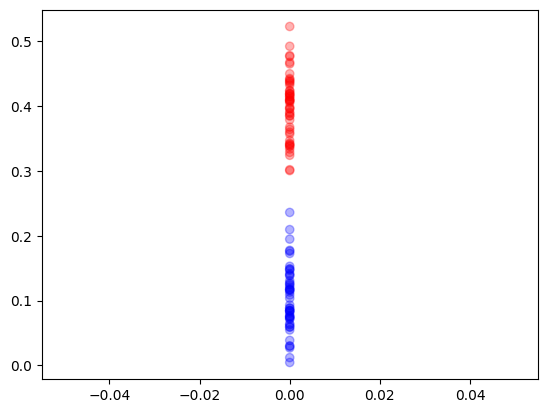

In [ ]:
plt.scatter(np.zeros_like(X[:, 0]), X[:, 1], c=y, alpha=0.3, cmap=cmap)
plt.show()

[0.77257828 0.22742172]


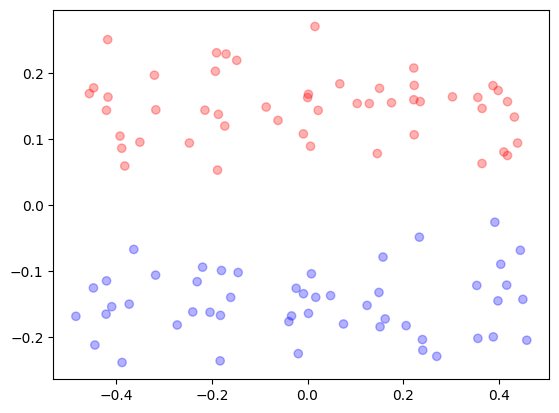

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(pca.explained_variance_ratio_)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3, cmap=cmap)
plt.show()

In [ ]:
model.fit(X_pca, y)
y_pred = model.predict(X_pca)
print(accuracy_score(y, y_pred))

1.0


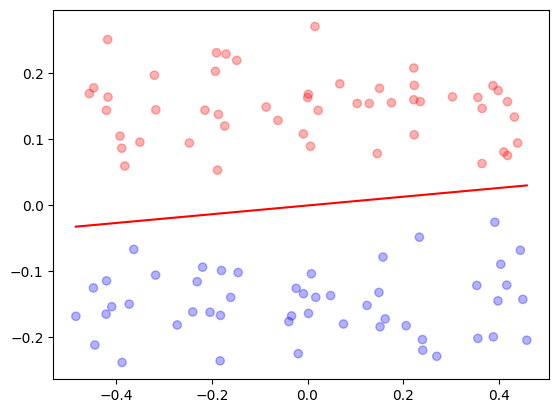

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.3, cmap=cmap)
plotHyperplan(model.coef_[0], model.intercept_[0], [
    X_pca[:,0].min(), X_pca[:,0].max()])
plt.show()

In [ ]:
model.fit(X_pca[:,:1], y)
y_pred = model.predict(X_pca[:,:1])
print(accuracy_score(y, y_pred))

0.52


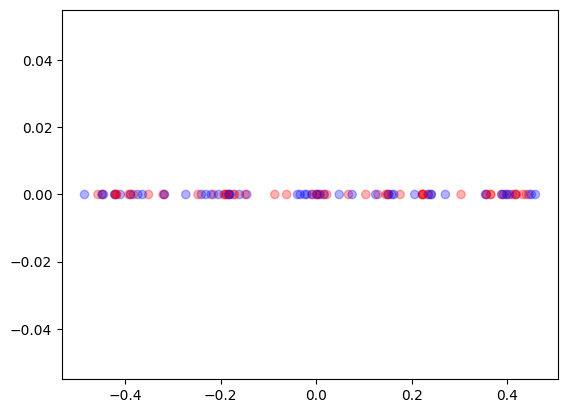

In [ ]:
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 1]), c=y, alpha=0.3, cmap=cmap)
plt.show()